In [1]:
import pandas as pd
import seaborn as sns

In [7]:
df = pd.read_csv("titanic.csv")

df.shape

(891, 12)

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
# df = sns.load_dataset("titanic")
# df.shape

(891, 15)

In [ ]:
# df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")
# df.shape

(891, 15)

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


No. of people traveling with Sibling or Spouse

In [11]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

No. of people traveling with Parents or Children

In [12]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Visualizing the distribution of `Parch`

<Axes: xlabel='Parch'>

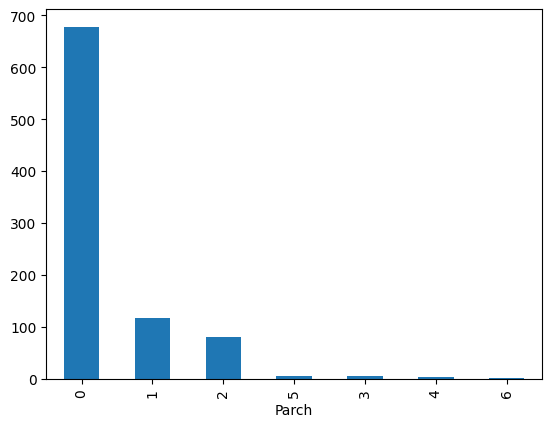

In [13]:
df['Parch'].value_counts().plot(kind='bar')


In [14]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Use one-hot encoding to encode `Sex` column.

In [15]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int)
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1


Use one-hot encoding for `Embarked`

In [16]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True, dtype=int)

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,0,1


In [18]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Sex_male         0
Embarked_Q       0
Embarked_S       0
dtype: int64


Use data imputation for `Age` column.

In [19]:
df['Age'].mode()

0    24.0
Name: Age, dtype: float64

Fill the missing value with median `Age`.

In [20]:
df.fillna({'Age': df['Age'].mode()[0]}, inplace=True)

In [21]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Sex_male         0
Embarked_Q       0
Embarked_S       0
dtype: int64

Remove `Cabin`

In [22]:
df = df.drop(columns=['Cabin'])

In [23]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64

Split the dataset in to train and test set

In [24]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [27]:
feature_column = ['Pclass', 'Age', 'SibSp', 'Parch']
target_column = 'Survived'

In [28]:
train_x = train[feature_column]
train_y = train[target_column]

test_x = test[feature_column]
test_y = test[target_column]

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(train_x, train_y)

LogisticRegression()

In [30]:
model.coef_

array([[-0.98563469, -0.0303822 , -0.21091393,  0.27658386]])

In [31]:
model.intercept_

array([2.60912559])

In [32]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(model.predict(train_x), train_y)

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.6910112359550562


In [33]:
y_pred = model.predict(test_x)
accuracy_score(y_pred, test_y)

0.7486033519553073

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

confusion = confusion_matrix(test_y, y_pred)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[95 10]
 [35 39]]


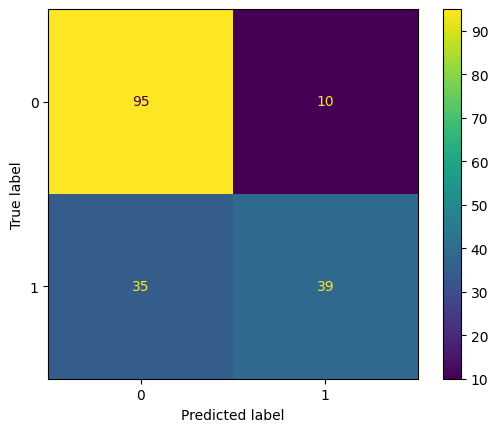

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot()


In [36]:

print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81       105
           1       0.80      0.53      0.63        74

    accuracy                           0.75       179
   macro avg       0.76      0.72      0.72       179
weighted avg       0.76      0.75      0.74       179



Q1. Plot the correlation matrix and select the most relevant features and then observe the result.

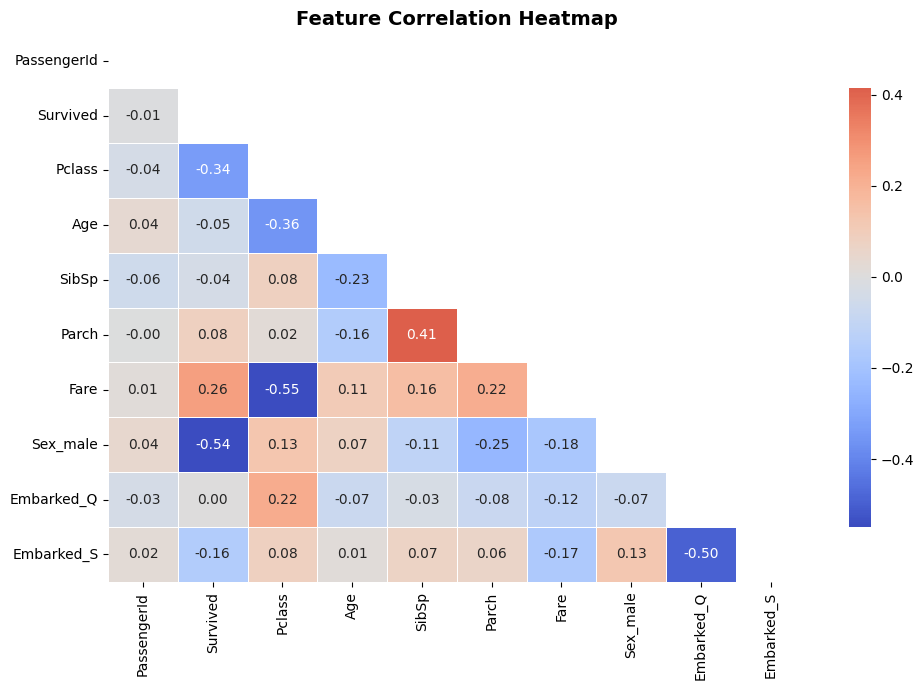

In [39]:
# Select numeric columns for correlation
import numpy as np
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=[np.number])

# Compute Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()